In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib, matplotlib.pyplot as plt
print("Matplotlib:", matplotlib.__version__, "Backend:", matplotlib.get_backend())


from asyncio import Event
import json
from msilib import Table
from turtle import pd
import streamlit as st
import pandas
import numpy as np
import os
import csv
import tempfile
import shutil
import logging
import re
import unicodedata
import sys
import subprocess
import time
import joblib
import matplotlib.pyplot as plt
import altair as alt


from datetime import datetime, timezone, timedelta
from tqdm import tqdm
from pathlib import Path
from typing import Iterable, Tuple, List, Set, Dict, Optional, Literal
from collections import Counter
from pathlib import Path
from git import Repo, exc as git_exc
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler

from dataclasses import dataclass
from github import Github, GithubException, UnknownObjectException, IncompletableObject

from ProjectHealthAnaysis import build_repo_health as project_health_main
from CommitExtractor import main as extract_repo_main

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, classification_report, confusion_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RangeSlider, TextBox, RadioButtons
from matplotlib.dates import date2num, num2date, AutoDateLocator, AutoDateFormatter

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

sys.path.append('../')
import Settings as cfg
import Utilities as util
import KnowledgeDistribution
import SocialTechnicalNetwork as std

Matplotlib: 3.9.1 Backend: inline


C:\Users\samut\AppData\Local\Temp\ipykernel_21120\979667563.py:10: DeprecationWarning: 'msilib' is deprecated and slated for removal in Python 3.13
  from msilib import Table


# Prediction LSTM

In [2]:
def view_df(df, name="DataFrame"):
    ''' Simple HTML table viewer for DataFrames '''
    import tempfile, webbrowser
    html = "\n".join([
        "<meta charset='utf-8'>",
        "<style>body{font-family:system-ui,Segoe UI,Arial}table{border-collapse:collapse}th,td{border:1px solid #ddd;padding:6px}th{position:sticky;top:0;background:#fafafa}</style>",
        f"<h3>{name}</h3>",
        df.to_html(index=False, escape=False),
    ])
    with tempfile.NamedTemporaryFile("w", delete=False, suffix=".html", encoding="utf-8") as f:
        f.write(html)
        webbrowser.open("file://" + f.name)

def build_response(df_in, N, label_col = "state"):

    d = df_in.sort_values(["dev", "date"]).copy()

    y = d[["dev", "date", label_col]].copy()
    
    y["active_to_inactive"]      = False
    y["non_coding_to_inactive"]  = False
    y["active_to_non_coding"]    = False

    for dev, g in d.groupby("dev", sort=False):
        g = g.sort_values("date").copy()
        next_state = g[label_col].shift(-N)  # look-ahead N days

        # current-state masks
        m_active     = (g[label_col] == "ACTIVE")
        m_noncoding  = (g[label_col] == "NON_CODING")

        # next-state masks (t+N)
        m_next_inact = (next_state == "INACTIVE") | (next_state == "GONE")
        m_next_nc    = (next_state == "NON_CODING")

        # assign ONLY within this group's rows
        y.loc[g.index, "active_to_inactive"]     = (m_active & m_next_inact).values
        y.loc[g.index, "non_coding_to_inactive"] = (m_noncoding & m_next_inact).values
        y.loc[g.index, "active_to_non_coding"]   = (m_active & m_next_nc).values

    y["transition_to_inactive"] = (
        y["active_to_inactive"] | y["non_coding_to_inactive"]
    )

    # final numeric response (avoid NaN->int errors)
    y["transition_to_inactive"] = y["transition_to_inactive"].astype("int8")
    y["active_to_inactive"]    = y["active_to_inactive"].astype("int8")
    y["non_coding_to_inactive"] = y["non_coding_to_inactive"].astype("int8")
    y["active_to_non_coding"]  = y["active_to_non_coding"].astype("int8")
    

    
    # we need to make a plot from these
    # i want to see a time line with data points showing when transitions happen

    return y

def build_predictor(data: pandas.DataFrame, user_inputs, tf_devs, state_col="state"):
    """
    Build X,y for inactivity prediction
    """
    df = data.copy()

    # normalize key cols
    df["date"] = pandas.to_datetime(df["date"]).dt.normalize()

    #remove the state col 
    df = df.drop(columns=[state_col])


    #output:
    #'dev', 'date', 'commits', 'issues', 'prs', 'files_changed',
    #   'lines_added', 'lines_removed', 'prs_review', 'prs_comment',
    #   'issues_commented', 'issues_activity', 'labeled', 'closed', 'commented',
    #   'mentioned', 'subscribed', 'referenced', 'renamed', 'issue_type_added',
    #   'unsubscribed', 'pinned', 'locked', 'reopened', 'assigned', 'unlabeled',
    #   'connected', 'milestoned', 'comment_deleted', 'unassigned', 'unpinned',
    #   'demilestoned', 'marked_as_duplicate', 'transferred',
    #   'unmarked_as_duplicate', 'unlocked', 'parent_issue_added',
    #   'parent_issue_removed', 'sub_issue_added', 'sub_issue_removed',
    #   'disconnected', 'nan', 'unknown_event', 'coding_day', 'nc_day',
    #   'break_day', 'th', 'len', 'event_day', 'state', 'total_interactions',
    #   'unique_partners', 'items_touched', 'new_interactions',
    #   'new_relationships', 'total_relationships', 'repeat_partners',
    #   'avg_time_delta', 'min_response_time', 'avg_interactions_per_user',
    #   'avg_distance_away'

    # small, editable feature list
    columns = ['commits', 'issues', 'prs', 'files_changed',
       'lines_added', 'lines_removed', 'prs_review', 'prs_comment',
       'issues_commented', 'issues_activity', 'labeled', 'closed', 'commented',
       'mentioned', 'subscribed', 'referenced', 'renamed', 'issue_type_added',
       'unsubscribed', 'pinned', 'locked', 'reopened', 'assigned', 'unlabeled',
       'connected', 'milestoned', 'comment_deleted', 'unassigned', 'unpinned',
       'demilestoned', 'marked_as_duplicate', 'transferred',
       'unmarked_as_duplicate', 'unlocked', 'parent_issue_added',
       'parent_issue_removed', 'sub_issue_added', 'sub_issue_removed',
       'disconnected', 'nan', 'unknown_event', 
       'total_interactions',
       'unique_partners', 'items_touched', 'new_interactions',
       'new_relationships', 'total_relationships', 'repeat_partners',
       'avg_time_delta', 'min_response_time', 'avg_interactions_per_user',
       'avg_distance_away' ] 

    X = df[["dev", "date"] + columns].copy()

    return X

def build_roll_feats(data , cols, rolls):
    out = []
    for dev, g in data.groupby("dev", sort=False):
        g = g.sort_values("date").copy()
        for c in cols:
            for R in rolls:
                g[f"{c}_rollmean{R}"] = g[c].rolling(R, min_periods=1).mean()
                g[f"{c}_rollsum{R}"]  = g[c].rolling(R, min_periods=1).sum()
        out.append(g)
    return pd.concat(out, axis=0)


# Visualization 

In [3]:

def view_df(df, name="DataFrame"):
    import tempfile, webbrowser
    html = "\n".join([
        "<meta charset='utf-8'>",
        "<style>body{font-family:system-ui,Segoe UI,Arial}table{border-collapse:collapse}th,td{border:1px solid #ddd;padding:6px}th{position:sticky;top:0;background:#fafafa}</style>",
        f"<h3>{name}</h3>",
        df.to_html(index=False, escape=False),
    ])
    with tempfile.NamedTemporaryFile("w", delete=False, suffix=".html", encoding="utf-8") as f:
        f.write(html)
        webbrowser.open("file://" + f.name)

def plot_user_transitions(meta):
    """Simple timeline plot showing transition points for each user"""
    import matplotlib.pyplot as plt
    

    transitions = meta[meta['transition_to_inactive'] == 1].copy()
    transitions_from_active = meta[meta['non_coding_to_inactive'] == 1].copy()
    transitions_from_noncoding = meta[meta['active_to_inactive'] == 1].copy()

    
    # Setup plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Get unique users and assign y-position
    users = meta['dev'].unique()
    user_pos = {user: i for i, user in enumerate(users)}
    
    # Plot horizontal line for each user
    for user, pos in user_pos.items():
        user_data = meta[meta['dev'] == user]
        ax.plot([user_data['date'].min(), user_data['date'].max()], 
                [pos, pos], 'gray', alpha=0.3, linewidth=2)
    
    # Plot transition dots
    if not transitions_from_active.empty:
        ax.scatter(transitions_from_active['date'], 
                  [user_pos[u] for u in transitions_from_active['dev']],
                  color='red', s=100, zorder=3, label='active to inactive')
        
    ax.scatter(transitions_from_noncoding['date'], 
          [user_pos[u] for u in transitions_from_noncoding['dev']],
          color='yellow', s=100, zorder=3, label='noncoding to inactive')
    
    # Formatting
    ax.set_yticks(range(len(users)))
    ax.set_yticklabels(users)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('User', fontsize=12)
    ax.set_title('User Activity Timeline with Transitions', fontsize=14)
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Get unique users and assign y-position
    users = meta['dev'].unique()
    user_pos = {user: i for i, user in enumerate(users)}
    
    # Plot horizontal line for each user
    for user, pos in user_pos.items():
        user_data = meta[meta['dev'] == user]
        ax.plot([user_data['date'].min(), user_data['date'].max()], 
                [pos, pos], 'gray', alpha=0.3, linewidth=2)

    ax.scatter(transitions['date'], 
          [user_pos[u] for u in transitions['dev']],
          color='green', s=100, zorder=3, label='Transitions')

    # Formatting
    ax.set_yticks(range(len(users)))
    ax.set_yticklabels(users)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('User', fontsize=12)
    ax.set_title('User Activity Timeline with Transitions', fontsize=14)
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_time( data, time_col = 'date' , value_col = 'commits' ):
    '''this function will plot a single time point against the day column for each user'''

    for user, user_data in data.groupby("dev"):
        plt.plot(user_data[time_col], user_data[value_col], label=user)

    plt.xlabel('Date')
    plt.ylabel(value_col)
    plt.title(f'{value_col} over Time')
    plt.legend()
    plt.show()


# Predictive models

In [4]:
def Elastic_Net_logistic(X_train, y_train, X_test, y_test, alpha=1.0):
    # we will get the test and train for both the response and predictor
    # we will have two df that look like this:
    #y cols: 'dev', 'date', 'transition_to_inactive'
    #x cols:'dev', 'date', 'commits', 'issues', 'prs', 'files_changed', 'lines_added', 'lines_removed', 'total_interactions', 'new_interactions'
    #make dev a catagorical value
    X_train = X_train['dev'].astype('category')
    X_test = X_test['dev'].astype('category')
    
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    # 3) fit your model (exactly your function)
    clf = Elastic_Net_logistic(Xtr, y_train["transition_to_inactive"].values.ravel(),
                            Xte,  y_test["transition_to_inactive"].values.ravel(),
                            alpha=0.5)  # <- l1_ratio; keep/change as you like

    # 4) get probabilities, then convert to 0/1 flags (use 0.5 for now)
    proba = clf.predict_proba(Xte)[:, 1]
    preds = (proba >= 0.5).astype(int)

    # 5) build the output DF with dev/date and your preds
    Y_preds = X_test[["dev", "date"]].copy()
    Y_preds["transition_to_inactive_prob"]  = proba
    Y_preds["transition_to_inactive_preds"] = preds

    # (optional) basic sanity checks
    print("AUROC (quick):", __import__("sklearn.metrics").metrics.roc_auc_score(
        y_test["transition_to_inactive"].values, proba
    ))
    Y_preds.head()

def XGBoost_classifier(X_train, y_train, X_test, y_test, params=None):
    if params is None:
        params = {
            'n_estimators': 100,
            'max_depth': 5,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'use_label_encoder': False,
            'eval_metric': 'logloss',
            'scale_pos_weight': (y == 0).sum() / (y == 1).sum()
        }
    clf = XGBClassifier(**params)
    clf.fit(X, y)
    return clf

def GRU_sequence(X, y, sequence_length=30, epochs=10, batch_size=32):
    

    num_features = X.shape[2]
    model = Sequential()
    model.add(GRU(64, input_shape=(sequence_length, num_features), return_sequences=False))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2)

    return model

def LSTM_sequence(X, y, sequence_length=30, epochs=10, batch_size=32):
    

    num_features = X.shape[2]
    model = Sequential()
    model.add(LSTM(64, input_shape=(sequence_length, num_features), return_sequences=False))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2)

    return model

We’ll automatically iterate across all devs as held-out folds.
 Users Selected inputs: {'Kfold_setting': None, 'selected_option': 'leave one DEV out', 'Ns_to_try': [1, 3, 7, 14, 30, 60, 90], 'include_state_feature': True} 


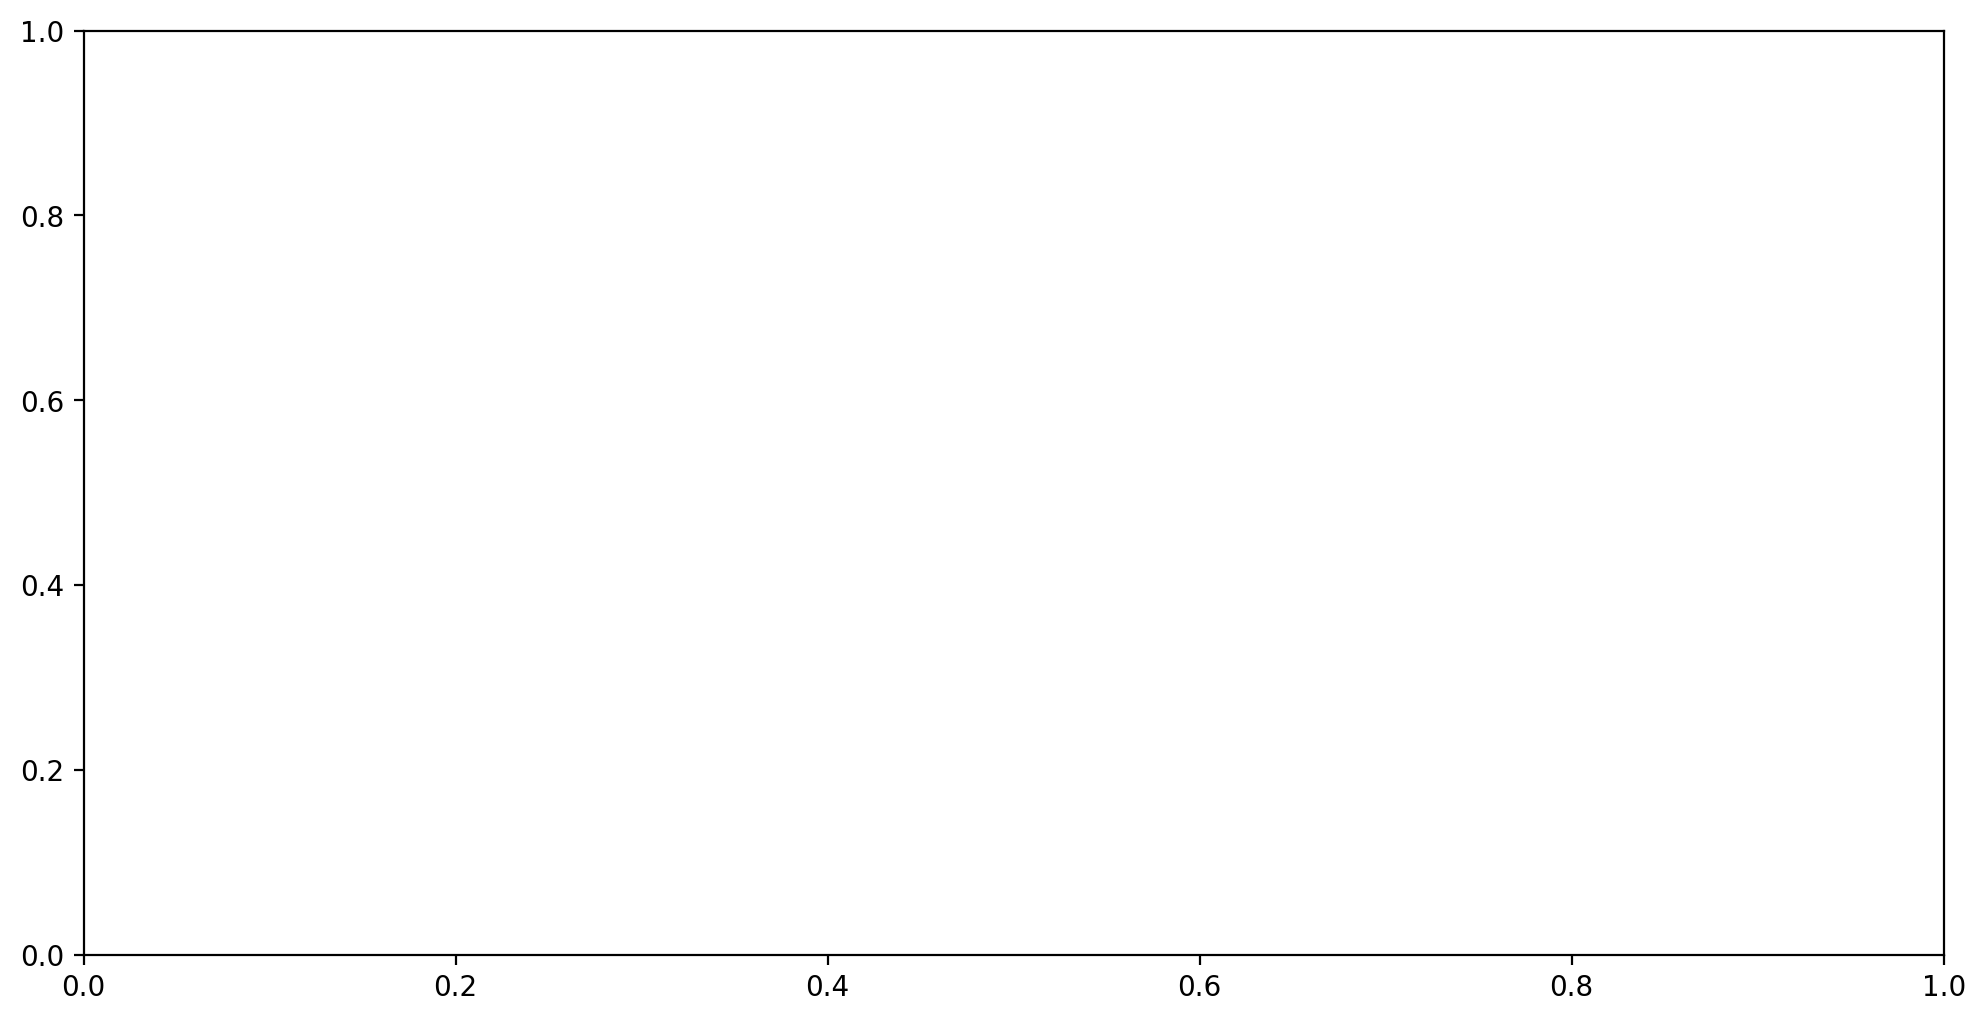

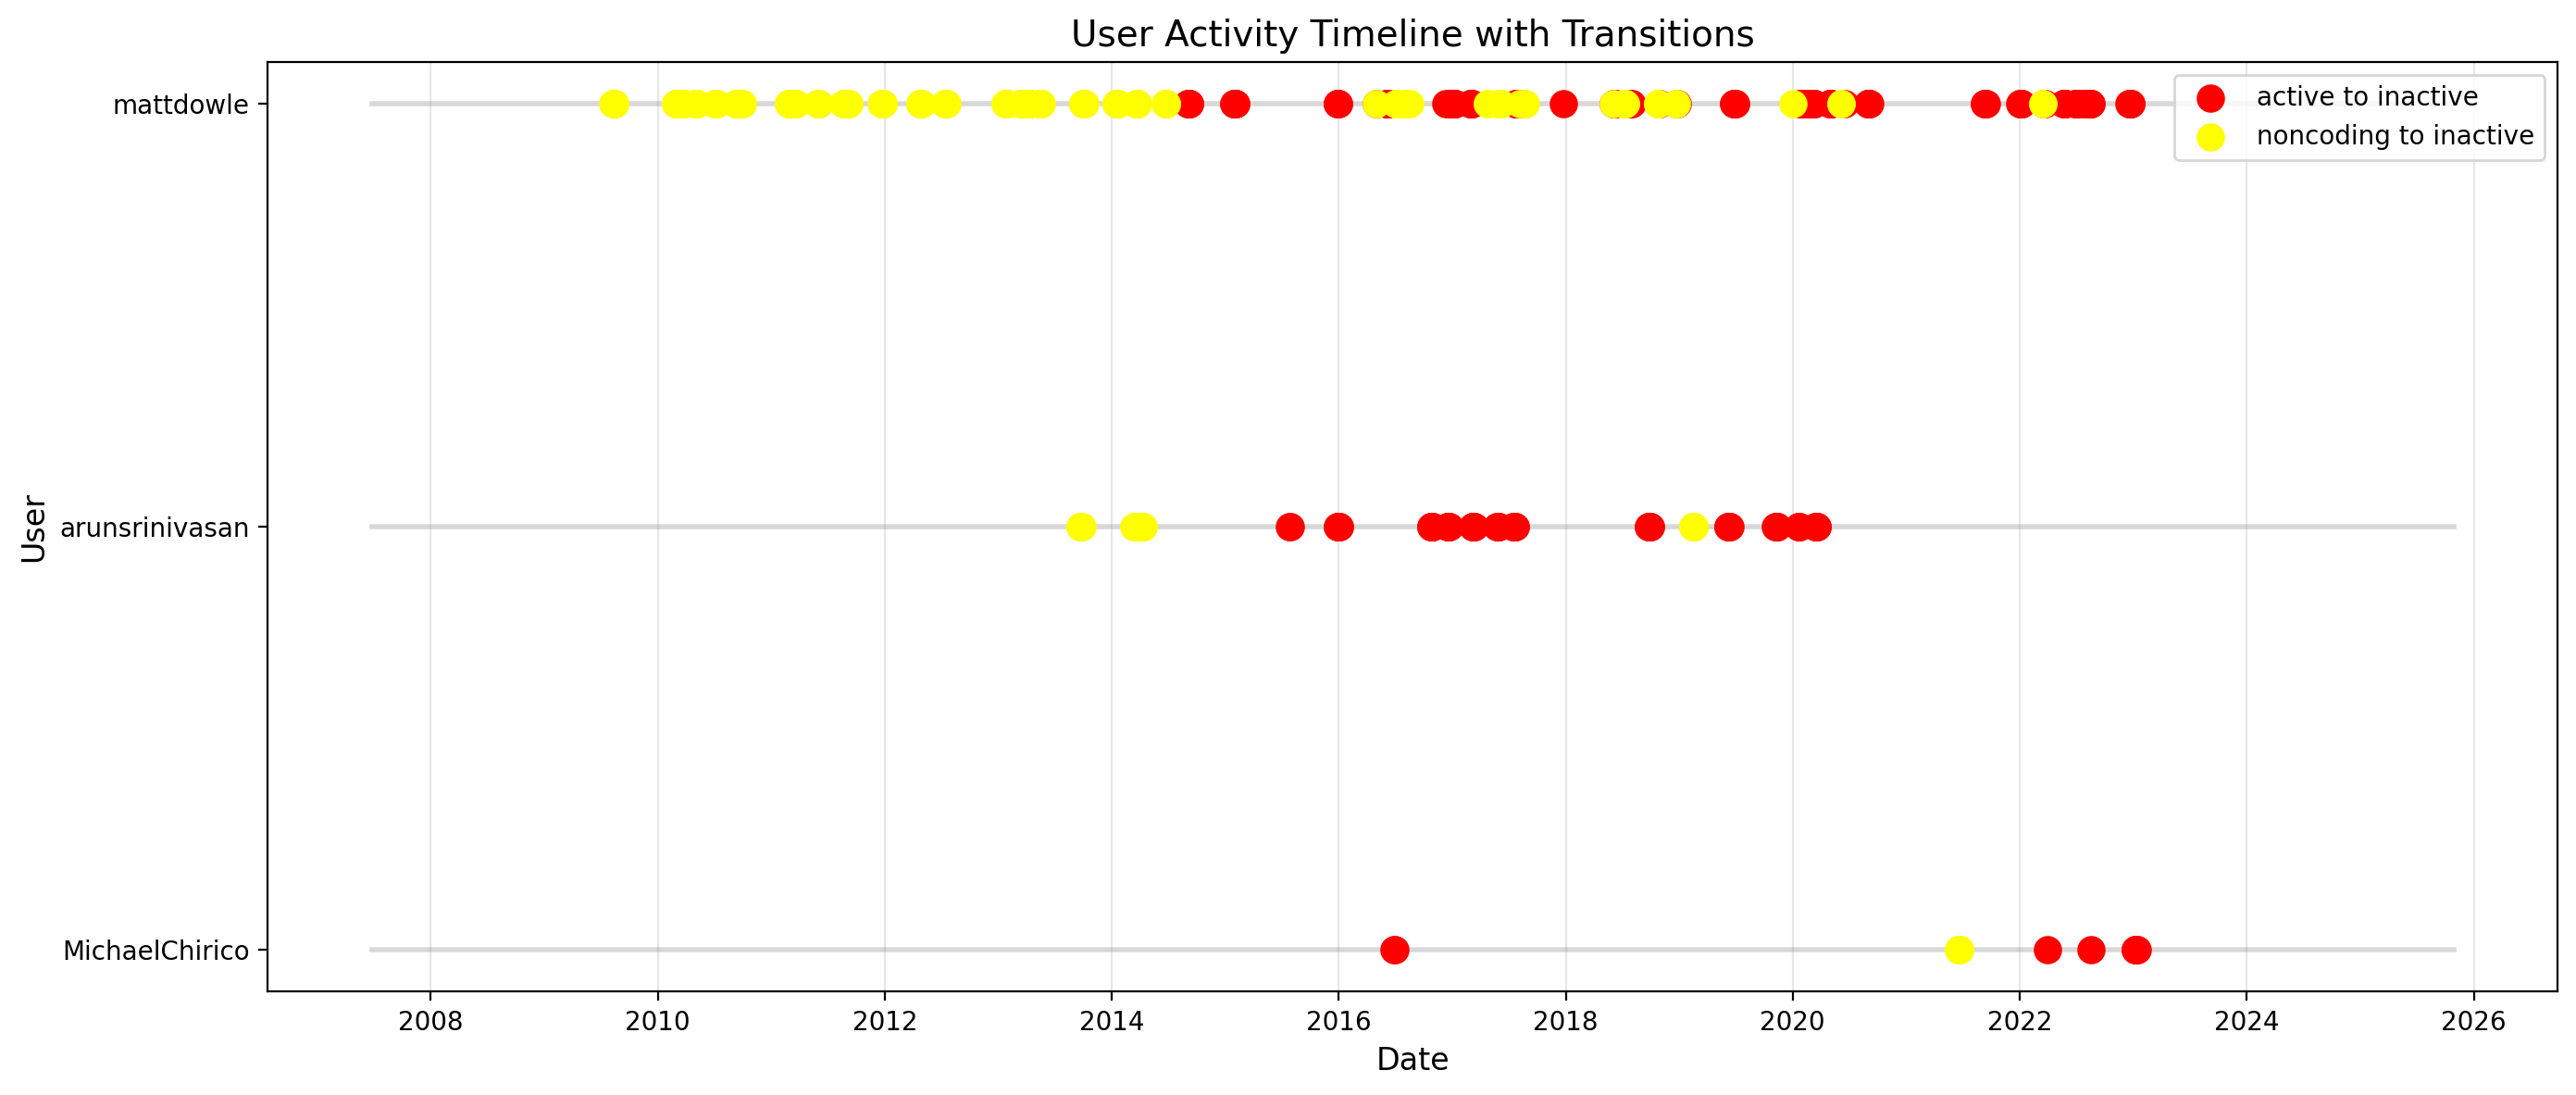

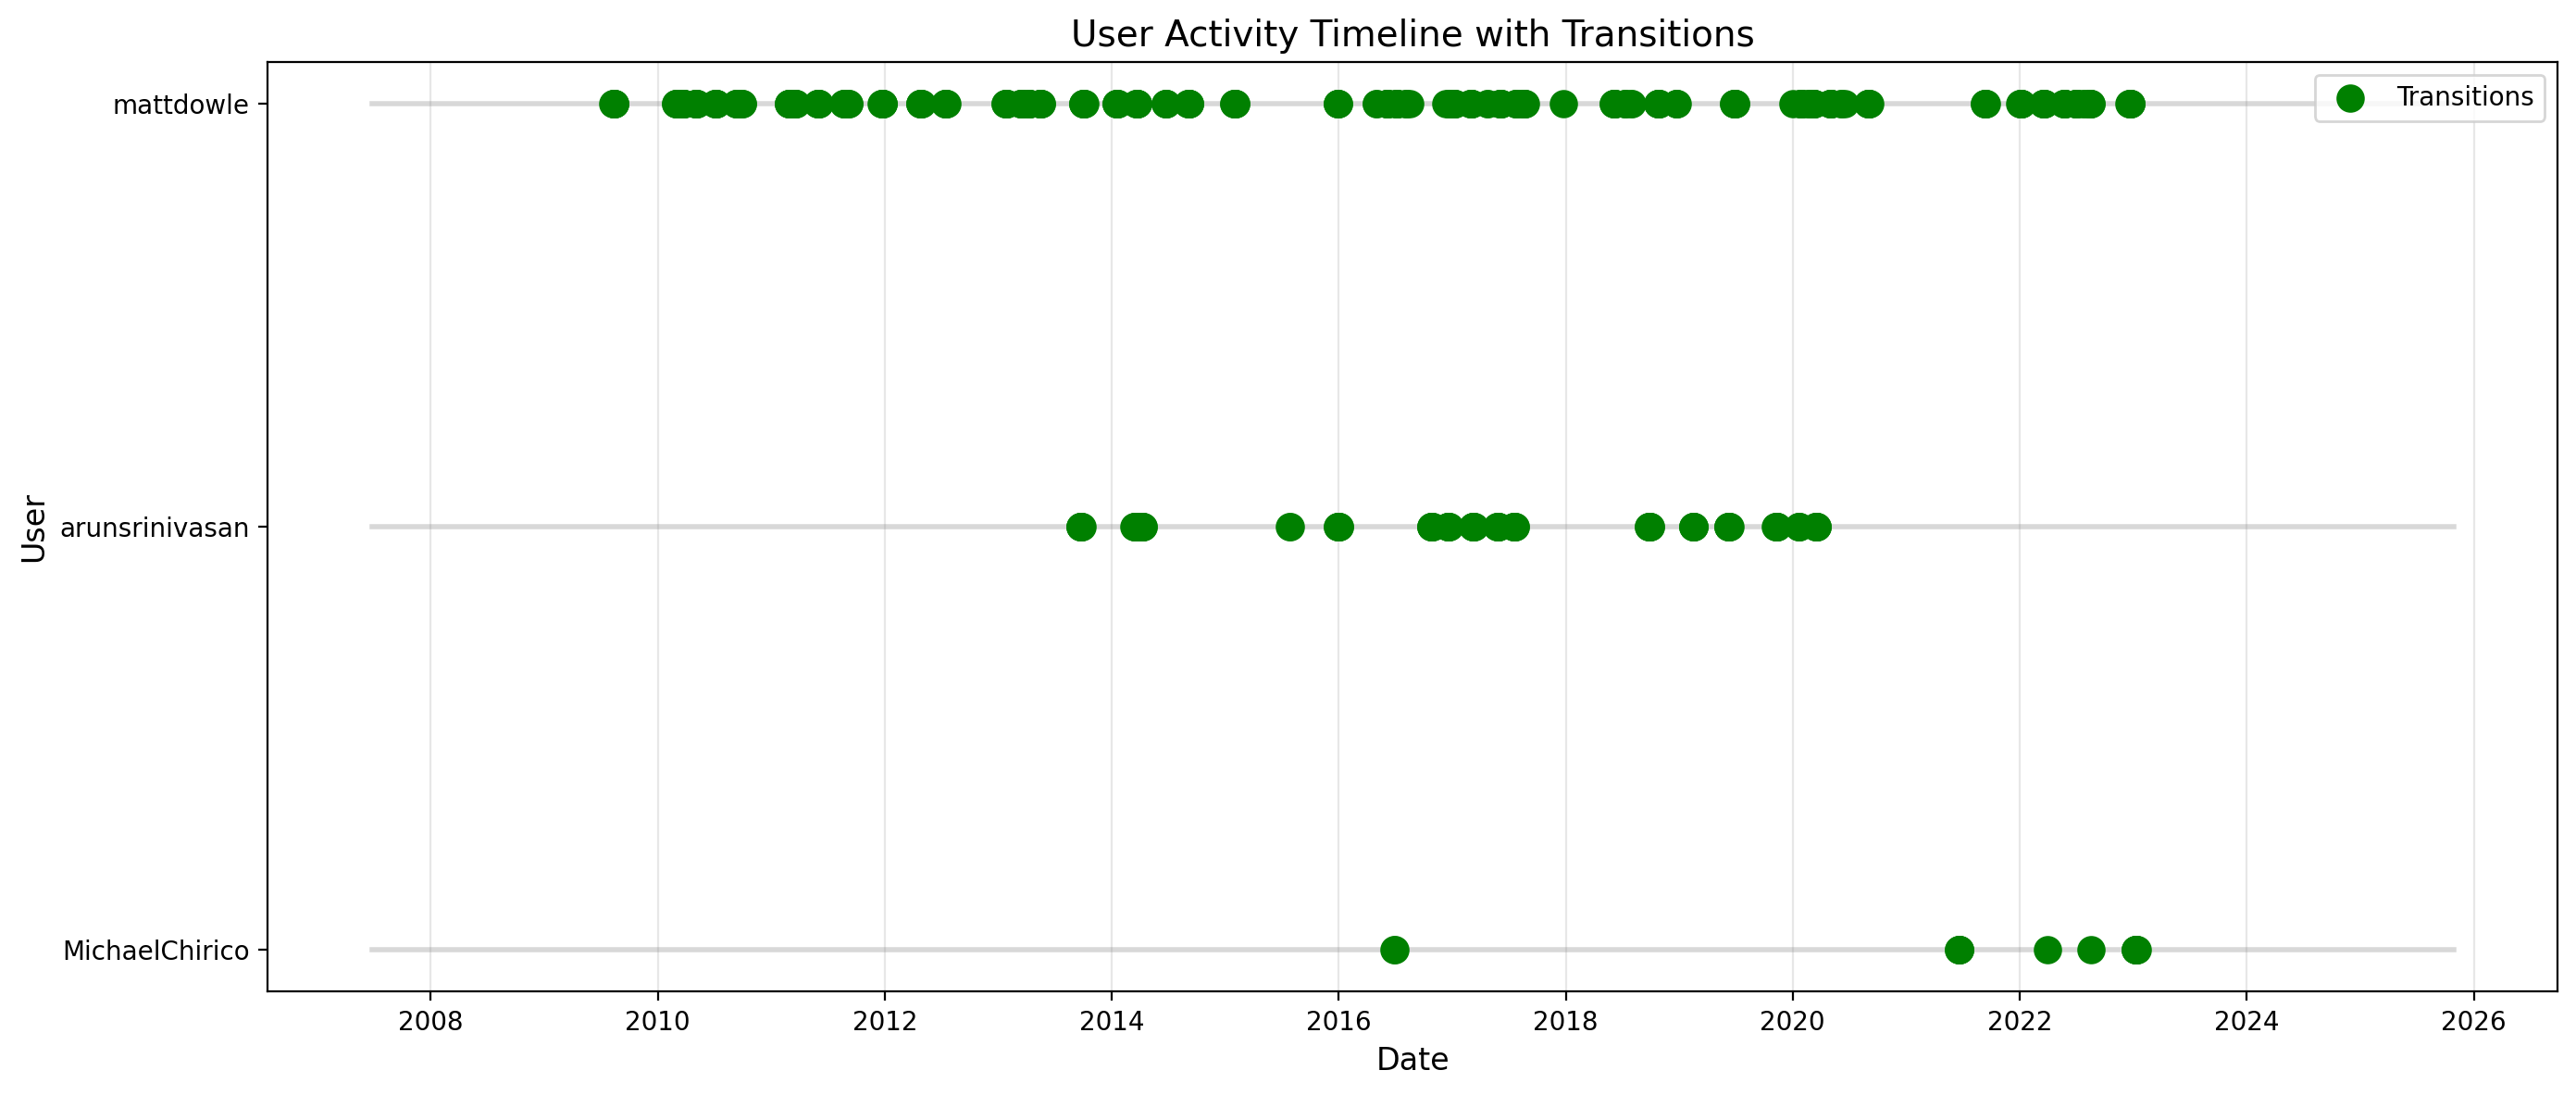

ValueError: could not convert string to float: 'mattdowle'

In [ ]:

def inactivity_prediction_main(data: pandas.DataFrame, user_inputs, tf_devs):
    """
    Minimal, readable pipeline:
    - make N-day-ahead target per dev (INACTIVE/GONE -> 1 else 0)
    - small, editable feature set
    - CV across N and split strategy
    """
    df = data.copy()

    # normalize key cols
    df["date"] = pandas.to_datetime(df["date"]).dt.normalize()

    # run across Ns
    rows_all = []
    
    X = build_predictor(df, user_inputs, tf_devs)


    y, meta = build_response(df, N=7, label_col="state")
    # plot metadata timeline
    # data looks like 
    #Meta
    #                dev       date  transition_to_inactive
    #6701  MichaelChirico 2007-06-25                       0
    #6702  MichaelChirico 2007-06-26                       0
    #6703  MichaelChirico 2007-06-27                       0
    #6704  MichaelChirico 2007-06-28                       0
    #6705  MichaelChirico 2007-06-29                       0
    #...              ...        ...                     ...
    #6696       mattdowle 2025-10-24                       0
    #6697       mattdowle 2025-10-25                       0
    #6698       mattdowle 2025-10-26                       0
    #6699       mattdowle 2025-10-27                       0
    #6700       mattdowle 2025-10-28                       0

    
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_user_transitions(meta)


    # we need to make the test train split for both the responce and predictors
    split_mode = user_inputs["selected_option"]
    
    if split_mode == "leave one DEV out":
        rows = []
        for dev, g in X.groupby("dev"):
            # for each dev we will make a split in the data 
            # we split he responce and predictor 
            X_train = X[X["dev"] != dev].copy()
            X_test  = X[X["dev"] == dev].copy()
            y_train = y[y["dev"] != dev].copy()
            y_test  = y[y["dev"] == dev].copy()
            #with 7–30 day lag/roll features
            rolls=(7, 14, 30)
            feature_cols = ['commits', 'issues', 'prs', 'files_changed', 'lines_added', 'lines_removed', 'total_interactions', 'new_interactions']
            X_roll_feats_train = build_roll_feats(X_train, feature_cols, rolls)
            X_roll_feats_test = build_roll_feats(X_test, feature_cols, rolls)
            
            ## commits 7
            #plot_time(X_roll_feats, "date", "commits_rollmean7")
            ## commits 14
            #plot_time(X_roll_feats, "date", "commits_rollmean14")
            ## issues 3
            #plot_time(X_roll_feats, "date", "issues_rollmean7")
            ## lines_added 3
            #plot_time(X_roll_feats, "date", "lines_added_rollmean7")

            # we need to make our models
            # we need to give baseline and tabular a the X_roll_feats for the testing set
            # the lstm needs the X for the testing
            #Baseline: Elastic-Net logistic .
            Elastic_Net_logistic(X_roll_feats_train, y_train, X_roll_feats_test, y_test, alpha=0.5)

    elif split_mode == "time-based split":
        # for a time based split, we will use the provided date as cutoff
        cutoff = pandas.to_datetime(split_arg).normalize()
        train_idx = X.index[(X["date"] <= cutoff)].tolist()
        test_idx  = X.index[(X["date"] >  cutoff)].tolist()
        splits = [(train_idx, test_idx)]
    else:
        raise ValueError(f"Unknown split mode: {split_mode}")
    

    
options = ["leave one DEV out", "leave one REPO out", "time-based split"]
selected_option = options[0]

include_state_feature = True
Ns_to_try = [1,3,7,14,30,60,90]
if selected_option == "leave one DEV out":
    print("We’ll automatically iterate across all devs as held-out folds.")
    Kfold_setting = None
elif selected_option == "leave one REPO out":
    print("Repo column not wired yet — skipping; use DEV or Time split for now.")
    Kfold_setting = None
else:  # time-based split
    Kfold_setting = "12/01/2023"
user_inputs = {
    "Kfold_setting": Kfold_setting,
    "selected_option": selected_option,
    "Ns_to_try": Ns_to_try,
    "include_state_feature": include_state_feature,
}
print( f" Users Selected inputs: {user_inputs} ")

repo_key = "Rdatatable/data.table"

data_file_path = Path(cfg.main_folder) / repo_key / cfg.social_technical_metrics_folder / cfg.social_technical_metrics_combined
    
if data_file_path.exists():
    data = pandas.read_csv(data_file_path, parse_dates=["date"], index_col=None)
view_df(data, name="Social-Technical Metrics Data")


tf_devs = ['mattdowle', 'MichaelChirico', 'arunsrinivasan']

inactivity_prediction_main(data, user_inputs, tf_devs)



# Rework

In [45]:

def make_confusion_mats(pred_df, thr_rf=0.5, thr_logit=0.5, per_dev=False, date_col="date"):
    """
    Window-level confusion metrics.
    A 'window' = contiguous run where y_true==1. It's a TP if any prediction==1 within that run.
    Also reports FP flags = predicted positives on rows where y_true==0.

    Returns a dict with 'rf' and 'logit' DataFrames of metrics (overall or per-dev).
    """
    df = pred_df.copy()
    df = df.dropna(subset=["y_true", "rf_proba", "logit_proba"])
    df["y_true"] = df["y_true"].astype(int)

    # threshold -> class labels
    df["rf_pred"]    = (df["rf_proba"]    >= thr_rf).astype(int)
    df["logit_pred"] = (df["logit_proba"] >= thr_logit).astype(int)

    # choose grouping (per-dev or all together)
    group_cols = ["dev"] if per_dev and "dev" in df.columns else []
    sort_cols  = group_cols + ([date_col] if date_col in df.columns else [])

    if sort_cols:
        df = df.sort_values(sort_cols)

    def _metrics_for_model(g: pd.DataFrame, model_col: str) -> pd.Series:
        # mark contiguous positive windows
        mask = g["y_true"].eq(1)
        # a new window starts where we transition from 0/NaN to 1
        starts = mask & (~mask.shift(fill_value=False))
        run_id = starts.cumsum()                         # monotonically increasing id
        g = g.copy()
        g["pos_run_id"] = np.where(mask, run_id, np.nan)

        # window hits: any prediction==1 inside the window
        if mask.any():
            hits = (g.loc[mask]
                     .groupby("pos_run_id")[model_col]
                     .apply(lambda s: int((s == 1).any())))
            TP_windows = int(hits.sum())
            total_windows = int(hits.size)
        else:
            TP_windows = 0
            total_windows = 0

        FN_windows = int(total_windows - TP_windows)

        # false flags = predicted positives outside any positive window (i.e., where y_true==0)
        FP_flags = int(((g["y_true"] == 0) & (g[model_col] == 1)).sum())

        # optional: true-negative windows aren't well-defined here; we report window-accuracy per your definition
        denom = TP_windows + FN_windows
        window_accuracy = (TP_windows / denom) if denom > 0 else np.nan

        # (also handy) counts for context
        total_flags = int((g[model_col] == 1).sum())
        true_flags_inside_windows = int(((g["y_true"] == 1) & (g[model_col] == 1)).sum())

        return pd.Series({
            "total_windows": total_windows,
            "Flagged_windows": TP_windows,
            "Missed_windows": FN_windows,
            "window_accuracy": window_accuracy,
            "Missed_flags": FP_flags,
            "total_flags": total_flags,
            "flags_inside_windows": true_flags_inside_windows,
        })

    # compute metrics per group, then aggregate if needed
    def _eval_model(model_col: str) -> pd.DataFrame:
        if group_cols:
            per = df.groupby(group_cols, dropna=False).apply(_metrics_for_model, model_col).reset_index()
            # overall row (summing counts and recomputing accuracy)
            overall_counts = per[["total_windows","Flagged_windows","Missed_windows","Missed_flags","total_flags","flags_inside_windows"]].sum()
            denom = overall_counts["Flagged_windows"] + overall_counts["Missed_windows"]
            overall_acc = (overall_counts["Flagged_windows"] / denom) if denom > 0 else np.nan
            overall = pd.DataFrame([{**{group_cols[0]: "__ALL__"}, **overall_counts.to_dict(), "window_accuracy": overall_acc}])
            return pd.concat([per, overall], ignore_index=True)
        else:
            return _metrics_for_model(df, model_col).to_frame().T

    out = {
        "rf": _eval_model("rf_pred"),
        "logit": _eval_model("logit_pred"),
    }
    return out
    
def run_prediction_pipeline():
    repo_key = "atom/atom"

    results_path =  cfg.main_folder + '/' + repo_key
    social_technical_metrics_folder = Path(results_path, cfg.social_technical_metrics_folder)
    timeline_combined = Path(social_technical_metrics_folder ,cfg.social_technical_metrics_combined)

    df = pd.read_csv(timeline_combined, low_memory=False).drop(columns=[c for c in pd.read_csv(timeline_combined, nrows=1).columns if c.lower().startswith("unnamed")], errors="ignore")

    devs= df["dev"].unique().tolist()

    y = build_response(df, 7, label_col = "state")
    df = df.merge(y[["dev", "date", "transition_to_inactive"]], on=["dev", "date"], how="left")

    label_col = "transition_to_inactive"
    date_col = "date"
    dev_col = "dev"



    df[label_col] = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int)
    df[date_col] = pd.to_datetime(df[date_col])

    num_cols = [c for c in df.columns if df[c].dtype.kind in "biufc" and c not in [label_col, date_col]] 

    # remove these items from the list num_cols: 'win_pauses', 'partial_lengths', 'win_th', 'last_th'
    excluded_cols = {'win_pauses', 'partial_lengths', 'win_th', 'last_th'}
    num_cols = [c for c in num_cols if c not in excluded_cols]


    print("num_cols:", num_cols)

    encoder = LabelEncoder()

    # Fit and transform the categorical column
    df['state_encoded'] = encoder.fit_transform(df['state'])

    LAGS=5
    combined_results = []

    for dev in devs:

        for col in num_cols:
            for l in range(1, LAGS+1):
                df[f"{col}_lag{l}"] = df.groupby(dev_col, observed=True)[col].shift(l)

        test_df = df[ df["dev"] == dev ]
        print(len(test_df))
        train_df = df[ df["dev"] != dev ]
        print(len(train_df))

        Xtr = train_df[[c for c in df.columns if any(c.endswith(f"_lag{i}") for i in range(1, LAGS+1))]]
        Xtr['state_encoded'] = df['state_encoded']
        Xtr = Xtr.dropna(axis=1, how='all')
        Xtr = Xtr.fillna(0)
        Xte = test_df[[c for c in df.columns if any(c.endswith(f"_lag{i}") for i in range(1, LAGS+1))]]
        Xte['state_encoded'] = df['state_encoded']
        Xte = Xte.dropna(axis=1, how='all')
        Xte = Xte.fillna(0)
        mask = ~Xte.isna().any(axis=1)


        ytr = train_df[label_col].astype(int)
        yte = test_df[label_col].astype(int)

        print(len(Xtr))
        print(len(ytr))
        print(len(Xte))
        print(len(yte))

        mask = ~Xte.isna().any(axis=1)


        len 

        log_clf = make_pipeline(StandardScaler(with_mean=True),
                                LogisticRegression(penalty="elasticnet", solver="saga",
                                                l1_ratio=0.5, C=1.0, class_weight="balanced",
                                                max_iter=1000))
        rf_clf  = RandomForestClassifier(n_estimators=400, min_samples_split=5, min_samples_leaf=2,
                                        n_jobs=-1, random_state=42, class_weight="balanced_subsample")
        log_clf.fit(Xtr,ytr)
        
        rf_clf.fit(Xtr,ytr)

        pred_df = pd.DataFrame({
            "dev": test_df[dev_col].values,
            "date": test_df[date_col].values,
            "y_true": yte.values,
            "rf_proba": rf_clf.predict_proba(Xte)[:,1],
            "logit_proba": log_clf.predict_proba(Xte)[:,1],
        })

        view_df(pred_df, name=f"Predictions for dev: {dev}")

        combined_results.append(pred_df)

    combined_results = pd.concat(combined_results, ignore_index=True)

    repo_key = "atomatom"
    combined_results.to_csv(f"{repo_key}_results.csv", index=False)


    metrics = make_confusion_mats(combined_results, thr_rf=0.5, thr_logit=0.5, per_dev=False)

    print(metrics['rf'])
    print(metrics['logit'])
    return combined_results, metrics


run_prediction_pipeline()

num_cols: ['commits', 'prs', 'issues', 'issue_activity', 'pr_activity', 'coding_day', 'nc_day', 'break_day', 'th', 'len', 'index', 'event_day', 'issue_total_interactions', 'issue_unique_partners', 'issue_items_touched', 'issue_new_interactions', 'issue_new_relationships', 'issue_total_relationships', 'issue_repeat_partners', 'issue_avg_time_delta', 'issue_min_response_time', 'issue_avg_response_time_distance_1', 'issue_avg_interactions_per_user', 'issue_avg_distance_away', 'pr_total_interactions', 'pr_unique_partners', 'pr_items_touched', 'pr_new_interactions', 'pr_new_relationships', 'pr_total_relationships', 'pr_repeat_partners', 'pr_avg_time_delta', 'pr_min_response_time', 'pr_avg_response_time_distance_1', 'pr_avg_interactions_per_user', 'pr_avg_distance_away']
1070
2784
2784
2784
1070
1070
2784
1070
1070
1070
2784
2784
   total_windows  Flagged_windows  Missed_windows  window_accuracy  \
0           55.0             20.0            35.0         0.363636   

   Missed_flags  total_

(                dev       date  y_true  rf_proba  logit_proba
 0     Corey Johnson 2011-08-19       0  0.570459     0.516862
 1     Corey Johnson 2011-08-20       0  0.216032     0.463779
 2     Corey Johnson 2011-08-21       0  0.103575     0.470122
 3     Corey Johnson 2011-08-22       0  0.144728     0.484584
 4     Corey Johnson 2011-08-23       0  0.253485     0.581786
 ...             ...        ...     ...       ...          ...
 3849    Nathan Sobo 2019-07-26       0  0.010590     0.234318
 3850    Nathan Sobo 2019-07-27       0  0.008345     0.151574
 3851    Nathan Sobo 2019-07-28       0  0.021285     0.200767
 3852    Nathan Sobo 2019-07-29       0  0.399125     0.355214
 3853    Nathan Sobo 2019-07-30       0  0.239597     0.258327
 
 [3854 rows x 5 columns],
 {'rf':    total_windows  Flagged_windows  Missed_windows  window_accuracy  \
  0           55.0             20.0            35.0         0.363636   
  
     Missed_flags  total_flags  flags_inside_windows  
  0     

# STOP

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

repo_key = "Rdatatable/data.table"

data_file_path = Path(cfg.main_folder) / repo_key / cfg.social_technical_metrics_folder / cfg.social_technical_metrics_combined
data = pd.read_csv(data_file_path, parse_dates=["date"])

data = data.dropna(subset=["dev", "date"])  # ensure key cols
data = data.sort_values(["dev", "date"]).reset_index(drop=True)

data = data.fillna(0)

data["dev"] = data["dev"].astype("category")


# ---- One-hot encode developer ----
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
dev_encoded = enc.fit_transform(data[["dev"]])
dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in enc.categories_[0]])
data = pd.concat([data.reset_index(drop=True), dev_df.reset_index(drop=True)], axis=1)



In [24]:
logo = LeaveOneGroupOut()

columns = ["dev","commits", "prs", "issues", "issue_activity", "pr_activity", "coding_day", "nc_day", "break_day", "th", "len", "index", "state", "event_day",
              "issue_total_interactions",
              "issue_unique_partners",
              "issue_items_touched",
              "issue_new_interactions",
              "issue_new_relationships",
              "issue_total_relationships",
              "issue_repeat_partners",
              "issue_avg_time_delta",
              "issue_min_response_time",
              "issue_avg_response_time_distance_1",
              "issue_avg_interactions_per_user",
              "issue_avg_distance_away",
              "pr_total_interactions",
              "pr_unique_partners",
              "pr_items_touched",
              "pr_new_interactions",
              "pr_new_relationships",
              "pr_total_relationships",
              "pr_repeat_partners",
              "pr_avg_time_delta",
              "pr_min_response_time",
              "pr_avg_response_time_distance_1",
              "pr_avg_interactions_per_user",
              "pr_avg_distance_away"
 ]

X = data[columns].copy()


y, meta = build_response(data, N=14, label_col="state")

y = y["transition_to_inactive"].astype(int)
groups = data["dev"]

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dev_test = groups.iloc[test_idx].unique()[0]
    print(f"Training on all except {dev_test}")





Training on all except MDQ6VXNlcjI3Nzk5OTg=
Training on all except MDQ6VXNlcjMxMDIwNDU=
Training on all except MDQ6VXNlcjc2MDYzODk=


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# --- parameters ---
N_DAYS = 90 # number of previous days to look back
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3

# --- prepare features and response ---
X = data[columns].copy()
y, meta = build_response(data, N=14, label_col="state")
y = y["transition_to_inactive"].astype(int)
groups = data["dev"]

# --- function to build sequences per developer ---
def create_sequences(df, labels, group, n_days):
    df = df.copy().sort_values("date")
    X_seq, y_seq = [], []
    for i in range(n_days, len(df)):
        X_seq.append(df.iloc[i-n_days:i].values)
        y_seq.append(labels.iloc[i])
    return np.array(X_seq), np.array(y_seq)

# --- model definition ---
def build_lstm_model(n_features, n_days):
    model = Sequential([
        LSTM(64, input_shape=(n_days, n_features), return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- cross-validation ---
logo = LeaveOneGroupOut()
results = []

for train_idx, test_idx in logo.split(X, y, groups):
    dev_test = groups.iloc[test_idx].unique()[0]
    print(f"\nTraining on all except {dev_test}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # standardize per-feature
    scaler = StandardScaler()
    # columns that are not 
    columns = X_train.columns.tolist() 
    columns.remove("dev")
    columns.remove("break_day")
    columns.remove("state")
    columns.remove("event_day")
    columns.remove("nc_day")

    X_train_scaled = scaler.fit_transform(X_train[columns])
    X_test_scaled = scaler.transform(X_test[columns])

    # group data by dev to build sequences
    X_train_seq, y_train_seq = [], []
    for dev in X.iloc[train_idx]["dev"].unique():
        dev_mask = (groups.iloc[train_idx] == dev)
        X_dev, y_dev = create_sequences(X_train_scaled[dev_mask], y_train[dev_mask], dev, N_DAYS)
        if len(X_dev) > 0:
            X_train_seq.append(X_dev)
            y_train_seq.append(y_dev)

    X_train_seq = np.concatenate(X_train_seq)
    y_train_seq = np.concatenate(y_train_seq)

    # test developer sequence
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, dev_test, N_DAYS)

    # train model
    model = build_lstm_model(n_features=X_train_seq.shape[2], n_days=N_DAYS)
    model.fit(X_train_seq, y_train_seq, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)

    # evaluate
    loss, acc = model.evaluate(X_test_seq, y_test_seq, verbose=0)
    print(f"Dev {dev_test} → Accuracy: {acc:.3f}")
    results.append((dev_test, acc))

print("\n--- Results Summary ---")
for dev, acc in results:
    print(f"{dev}: {acc:.3f}")



Training on all except MDQ6VXNlcjI3Nzk5OTg=


AttributeError: 'numpy.ndarray' object has no attribute 'sort_values'

In [7]:
from __future__ import annotations
import csv
from pathlib import Path
from typing import List, Iterable, Optional



EXPECTED_HEADER = [
    "repo","sha","committed_at","author_login","author_name","author_email",
    "committer_login","file_path","status","additions","deletions","changes","previous_filename"
]

BAD_INDEX_NAMES = {"Unnamed: 0", "index", "_index", ""}
STATUS_VALS = {"added","modified","removed","renamed","copied","changed"}

def _read_header(path: Path) -> List[str]:
    with path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
    return [h.strip() for h in header]

def _sanitize_header(header: List[str]) -> List[str]:
    # Drop a leading accidental index column in header if present
    if header and header[0].strip() in BAD_INDEX_NAMES and len(header) > 1:
        return header[1:]
    return header

def _repair_row_len(row: List[str], expected_len: int) -> List[str]:
    """Fix common length issues:
       - extra trailing empty cells -> trim
       - too many cells -> keep first expected_len
       - too few cells -> right-pad with empty strings
    """
    # Trim whitespace
    row = [c.strip() for c in row]

    if len(row) == expected_len + 1 and row[-1] == "":
        return row[:-1]
    if len(row) > expected_len:
        return row[:expected_len]
    if len(row) < expected_len:
        return row + [""] * (expected_len - len(row))
    return row

def _shift_if_status_in_file_path(header: List[str], rows: Iterable[List[str]]) -> List[List[str]]:
    """If we still see status (e.g., 'modified') in file_path col because of off-by-one,
       try to shift columns for those rows only.
    """
    idx = {name: i for i, name in enumerate(header)}
    out_rows: List[List[str]] = []
    for row in rows:
        # be safe if row length changed
        row = row[:len(header)]
        fp = row[idx["file_path"]]
        if fp in STATUS_VALS:
            # Heuristic: committer_login should NOT look like a path, file_path should.
            # If committer_login *does* look like a path, then the whole tail is shifted left.
            cl = row[idx["committer_login"]]
            looks_like_path = ("/" in cl) or ("\\" in cl) or (cl.endswith(".js") or cl.endswith(".ts") or cl.endswith(".py") or cl.endswith(".java") or "." in cl)
            if looks_like_path:
                # Perform a right shift of file_path..previous_filename by 1
                # [committer_login]->unchanged, but we want that value to go to file_path
                # The misalignment we see is usually:
                #   committer_login := <actual file_path>
                #   file_path       := status
                #   status          := additions
                #   additions       := deletions
                #   deletions       := changes
                #   changes         := previous_filename
                #   previous_filename := "" (lost)
                row[idx["previous_filename"]] = row[idx["changes"]]
                row[idx["changes"]]           = row[idx["deletions"]]
                row[idx["deletions"]]         = row[idx["additions"]]
                row[idx["additions"]]         = row[idx["status"]]
                row[idx["status"]]            = row[idx["file_path"]]
                row[idx["file_path"]]         = row[idx["committer_login"]]
                # leave committer_login as-is (likely empty/nonnormal in these cases)
        out_rows.append(row)
    return out_rows

def clean_per_file_commits_inplace(path: str | Path, expected_header: Optional[List[str]] = None) -> None:
    """Cleans the CSV in place:
       - Removes a leading accidental index column if present
       - Ensures every row matches header length (drops a single trailing empty field)
       - Heuristically repairs rows where `file_path` erroneously holds a status value
    """
    p = Path(path)
    header = _read_header(p)
    header = _sanitize_header(header)

    if expected_header is None:
        expected_header = header
    else:
        # If provided, we use the expected header instead of the file's header
        pass

    tmp = p.with_suffix(p.suffix + ".tmp")

    with p.open("r", encoding="utf-8", newline="") as fin, tmp.open("w", encoding="utf-8", newline="") as fout:
        reader = csv.reader(fin)
        original_header = next(reader)
        # If original header had a leading index column, ignore it when writing
        if original_header and original_header[0].strip() in BAD_INDEX_NAMES and len(original_header) > 1:
            # consume rows while also dropping the first field
            # but we still repair lengths to expected
            fixed_rows = []
            for row in reader:
                row = row[1:]  # drop leading index column cell
                row = _repair_row_len(row, len(expected_header))
                fixed_rows.append(row)
        else:
            # normal path
            fixed_rows = []
            for row in reader:
                row = _repair_row_len(row, len(expected_header))
                fixed_rows.append(row)

        # Second pass: shift rows if file_path contains a status and committer_login looks like a path
        fixed_rows = _shift_if_status_in_file_path(expected_header, fixed_rows)

        writer = csv.writer(fout)
        writer.writerow(expected_header)
        for row in fixed_rows:
            writer.writerow(row)

    # Replace original file
    tmp.replace(p)

def load_per_file_commits(path: str | Path):
    """Convenience loader after cleaning, returning a pandas DataFrame."""
    import pandas as pd
    df = pd.read_csv(
        path,
        dtype=str,
        keep_default_na=False,
        engine="python"
    )
    view_df(df, name="Raw per-file commits data")
    # Type normalization commonly expected downstream
    if "additions" in df: df["additions"] = pd.to_numeric(df["additions"], errors="coerce").fillna(0).astype(int)
    if "deletions" in df: df["deletions"] = pd.to_numeric(df["deletions"], errors="coerce").fillna(0).astype(int)
    if "changes"   in df: df["changes"]   = pd.to_numeric(df["changes"],   errors="coerce").fillna(0).astype(int)
    if "committed_at" in df:
        df["committed_at"] = pd.to_datetime(df["committed_at"], errors="coerce", utc=True)

    return df


repos = ["aseprite/aseprite",
"jekyll/jekyll",
"laravel/framework",
"jquery/jquery",
"fastlane/fastlane",
"crystal-lang/crystal",
"BabylonJS/Babylon.js",
"elixir-lang/elixir",
"laravel/framework",
"elixirlang/elixir",
"JabRef/jabref",
"github/linguist",
"MinecraftForge/MinecraftForge",
"Rdatatable/data.table",
"JabRef/jabref",
"SpaceVim/SpaceVim",
"flutter/flutter",
"ionic-team/ionic-framework",
"atom/atom",
"facebook/react",
"rails/rails",
"nodejs/node"
]


for repo in repos:
    # move back one file for the working directory

    file_path = Path("../Organizations") / repo / "per_file_commits.csv"
    if not file_path.exists():
        print(f"File not found: {file_path}")
        continue
    else:
        print(f"Processing file: {file_path}")
        df = load_per_file_commits(file_path)


Processing file: ..\Organizations\aseprite\aseprite\per_file_commits.csv
File not found: ..\Organizations\jekyll\jekyll\per_file_commits.csv
File not found: ..\Organizations\laravel\framework\per_file_commits.csv
File not found: ..\Organizations\jquery\jquery\per_file_commits.csv
File not found: ..\Organizations\fastlane\fastlane\per_file_commits.csv
File not found: ..\Organizations\crystal-lang\crystal\per_file_commits.csv
File not found: ..\Organizations\BabylonJS\Babylon.js\per_file_commits.csv
File not found: ..\Organizations\elixir-lang\elixir\per_file_commits.csv
File not found: ..\Organizations\laravel\framework\per_file_commits.csv
File not found: ..\Organizations\elixirlang\elixir\per_file_commits.csv
Processing file: ..\Organizations\JabRef\jabref\per_file_commits.csv


KeyboardInterrupt: 

# data timeline

In [ ]:
import pandas as pd

# --- helpers ---------------------------------------------------------------

COMMON_TIME_COLS = ["created_at", "timestamp", "event_time", "time", "date"]
# prefer stable IDs; fall back to names/usernames
COMMON_USER_COLS = [
    "author_id", "user_id", "actor_id", "committer_id", "creator_id", "login",
    "user", "author_name", "committer_name", "username"
]

def _infer_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not infer column from candidates: {candidates}. Available: {list(df.columns)[:20]}")

def aggregate_daily_counts(
    df: pd.DataFrame, 
    *, 
    time_col: str | None = None, 
    user_col: str | None = None,
    source: str | None = None,
) -> pd.DataFrame:
    """
    Return per-day per-dev row counts:
    columns -> ['day','dev','activity_count'] (+ optional 'source')
    """
    if df is None or len(df) == 0:
        out = pd.DataFrame(columns=["day", "dev", "activity_count"] + (["source"] if source else []))
        return out

    # pick columns if not provided
    time_col = time_col or _infer_col(df, COMMON_TIME_COLS)
    user_col = user_col or _infer_col(df, COMMON_USER_COLS)

    # to datetime (tolerant), normalize to day (naive date)
    ts = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    day = ts.dt.tz_convert(None).dt.floor("D")  # strip tz; floor to midnight

    # coerce user ids/names to string (keeps IDs readable)
    dev = df[user_col].astype(str)

    g = (
        pd.DataFrame({"day": day, "dev": dev})
        .dropna(subset=["day", "dev"])
        .groupby(["day", "dev"], as_index=False)
        .size()
        .rename(columns={"size": "activity_count"})
    )

    if source:
        g["source"] = source
    return g

def aggregate_all_sources(raw_data_tables: dict) -> pd.DataFrame:
    """
    Apply aggregate_daily_counts to each table and concat.
    Adds a 'source' column using the dict key (e.g., 'commits', 'issues', ...).
    """
    pieces = []
    for key, df in (raw_data_tables or {}).items():
        if df is None:
            continue
        pieces.append(aggregate_daily_counts(df, source=key))
    if not pieces:
        return pd.DataFrame(columns=["day", "dev", "activity_count", "source"])
    out = pd.concat(pieces, ignore_index=True)
    # if you want totals across all sources per day/dev, you can also compute:
    # totals = out.groupby(["day","dev"], as_index=False)["activity_count"].sum()
    return out

# --- examples --------------------------------------------------------------

# Example: commits table you described
# columns: repo, created_at, author_id, author_name, author_email, committer_id, sha, filename_list, fileschanged_count, additions_sum, deletions_sum

daily_commits = aggregate_daily_counts(
    raw_data_tables["commits"],
    time_col="created_at",     # explicit (optional; it would be inferred)
    user_col="author_id",      # explicit (optional; prefer stable ID)
    source="commits"           # tag the origin (optional)
)

# If you want all sources in one long table:
daily_all = aggregate_all_sources(raw_data_tables)

# If you ONLY want the minimal 3 columns:
daily_commits_min = daily_commits[["day", "dev", "activity_count"]]


In [8]:
def add_activity_columns(data):
    """
    Adds:
      - coding_total = commits + prs
      - noncoding_total = issues + issue_activity + pr_activity
    to a copy of the dataframe and returns it.
    """
    d = data.copy()

    # make sure missing values don't break the sums
    for c in ['commits', 'prs', 'issues', 'issue_activity', 'pr_activity']:
        if c in d.columns:
            d[c] = d[c].fillna(0)
        else:
            # if some column is missing, just create it as zeros
            d[c] = 0.0

    d['coding_total'] = d['commits'] + d['prs']
    d['noncoding_total'] = d['issues'] + d['issue_activity'] + d['pr_activity']

    return d


def plot_dev_timelines(
    data,
    dev_col='dev',
    date_col='date',
    prob_col='rf_proba',
    pred_col='rf_preds',
    trans_col='transition_to_inactive',
    state_col='state',
    thr=0.5,
):
    """
    For each developer, creates a figure with:
      - Top axis: bars for coding_total and noncoding_total,
                  with background colored by state.
      - Bottom axis: probability over time, red bars for transitions,
                     and markers where prediction == 1.

    Assumes `data` already has daily rows per dev.
    """

    # Make sure we have activity columns
    d = add_activity_columns(data)
    d = d.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    # State -> background color mapping
    state_colors = {
        'ACTIVE':  'lightgreen',
        'NONCODING': 'khaki',
        'INACTIVE': 'lightcoral',
        'GONE': 'lightgray',  # just in case
    }

    # Group by developer
    for dev, g in d.groupby(dev_col):
        g = g.sort_values(date_col)

        dates = g[date_col]
        coding = g['coding_total']
        noncoding = g['noncoding_total']

        fig, (ax1, ax2) = plt.subplots(
            2, 1,
            figsize=(14, 7),
            sharex=True,
            gridspec_kw={'height_ratios': [2, 1]}
        )
        fig.suptitle(f"Developer: {dev}", fontsize=14)

        # -------------------
        # TOP PANEL: activity
        # -------------------

        # Background by state
        # We color each day as a vertical band spanning that day.
        if state_col in g.columns:
            for idx, row in g.iterrows():
                state = row[state_col]
                color = state_colors.get(state, None)
                if color is None:
                    continue

                day = row[date_col]
                # "width" of one day; here we take half-day to each side
                ax1.axvspan(day - pd.Timedelta(hours=12),
                            day + pd.Timedelta(hours=12),
                            color=color, alpha=0.2)

        # Bar positions (a tiny offset so coding & noncoding aren't exactly overlapping)
        # We’ll use side-by-side bars.
        x = np.arange(len(dates))
        width = 0.4

        ax1.bar(x - width/2, coding, width, label='Coding (commits + PRs)')
        ax1.bar(x + width/2, noncoding, width, label='Non-coding (issues + activity)')

        ax1.set_ylabel("Daily activity (count)")
        ax1.set_title("Activity timeline")
        ax1.legend(loc='upper right')

        # Use dates as x-ticks
        ax1.set_xticks(x)
        ax1.set_xticklabels([d.date() for d in dates], rotation=45, ha='right')

        # -------------------------
        # BOTTOM PANEL: prediction
        # -------------------------

        has_prob = prob_col in g.columns
        has_pred = pred_col in g.columns
        has_trans = trans_col in g.columns

        if has_prob:
            probs = g[prob_col].astype(float)
            ax2.plot(x, probs, linestyle='-', marker=None, label='Predicted probability')

            # Threshold line
            ax2.axhline(thr, linestyle='--', label=f'Threshold = {thr}')

        # Red bars for true transitions
        if has_trans:
            trans_mask = g[trans_col].fillna(0).astype(int) == 1
            ax2.bar(
                x[trans_mask],
                [1.0] * trans_mask.sum(),
                width=0.9,
                bottom=0,
                alpha=0.2,
                color='red',
                label='Transition to inactive (true)'
            )

        # Mark predicted positive days
        if has_pred and has_prob:
            pred_mask = g[pred_col].fillna(0).astype(int) == 1
            ax2.scatter(
                x[pred_mask],
                probs[pred_mask],
                marker='o',
                edgecolor='black',
                facecolor='none',
                label='Predicted inactive (rf_preds=1)'
            )

        ax2.set_ylabel("Probability")
        ax2.set_xlabel("Date")
        ax2.set_title("Prediction timeline")

        # Avoid duplicated labels in legend
        handles, labels = ax2.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax2.legend(by_label.values(), by_label.keys(), loc='upper left')

        # Use same date ticks as top panel
        ax2.set_xticks(x)
        ax2.set_xticklabels([d.date() for d in dates], rotation=45, ha='right')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


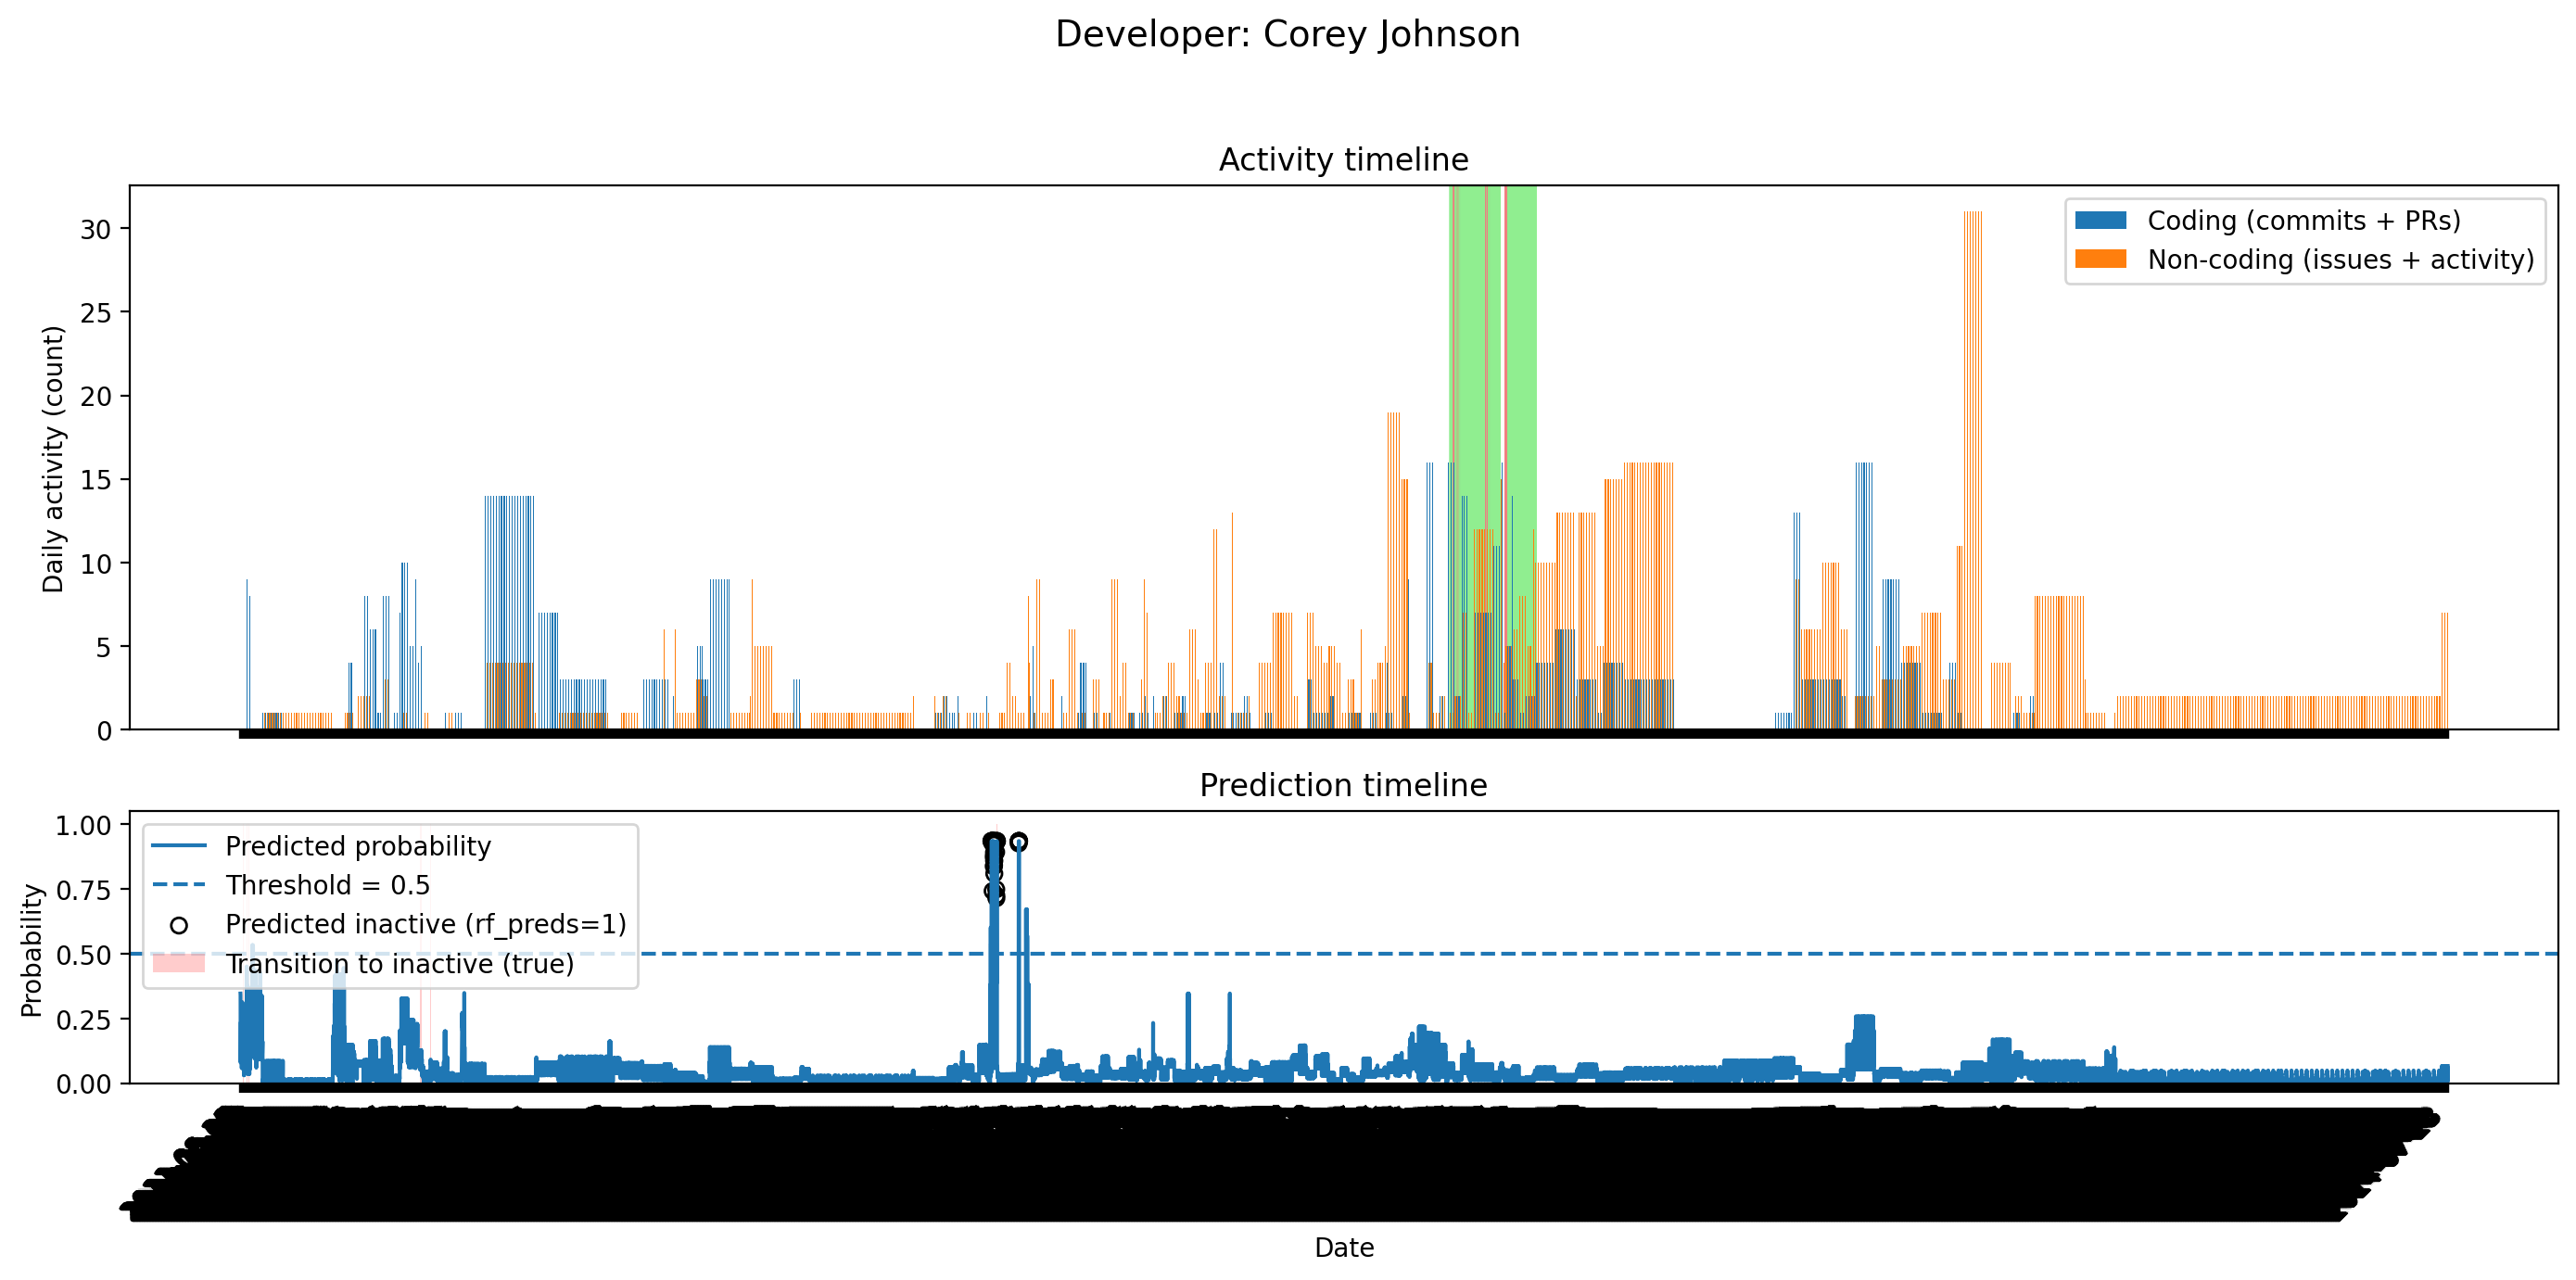

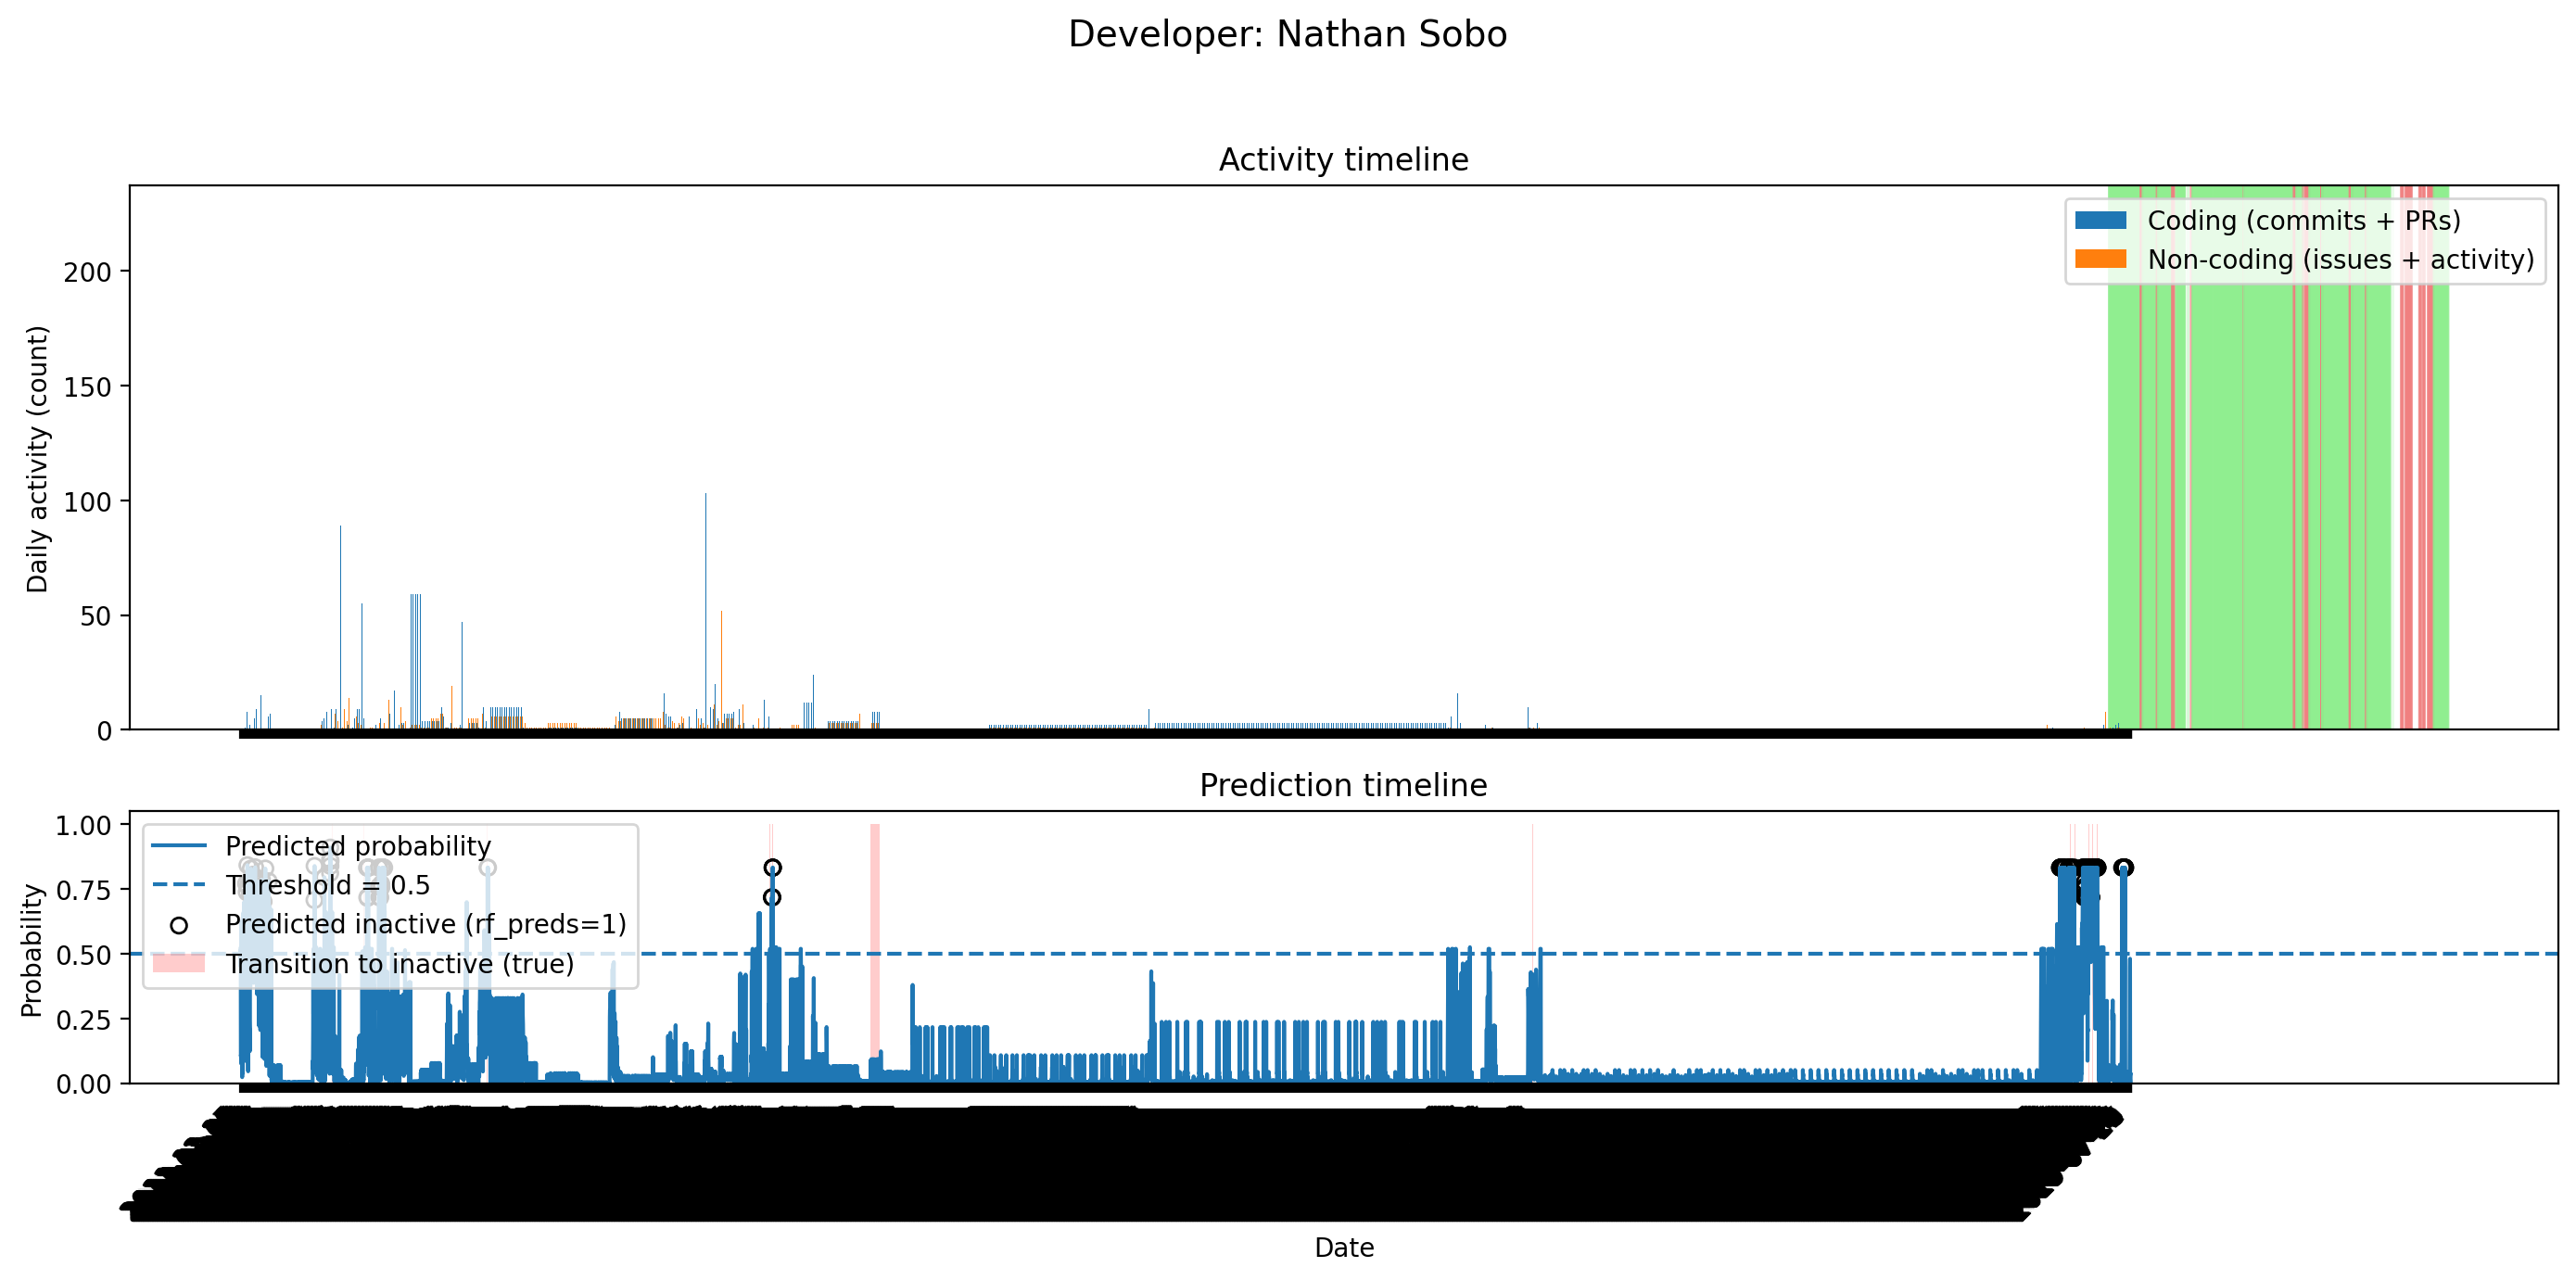

In [9]:
path = r"D:\Users\samut\OneDrive\Documents\GitHub\developersInactivityAnalysisCOPY\Extractors\final_data_with_predictions.csv"

df = pandas.read_csv(path)

df = add_activity_columns(df)

plot_dev_timelines(df)
